# Credit Card Fraud Dataset: Exploratory Data Analysis

This notebook is meant to be a **comprehensive first-pass analysis** of the dataset before preprocessing and modeling.

It is organized to answer these questions:

1. What does the dataset look like?
2. Are there missing values or duplicate rows?
3. Are any columns stored with the wrong data type?
4. Are there formatting inconsistencies in text columns?
5. Are there suspicious values or outliers?
6. How imbalanced is the fraud target?
7. What features might be worth engineering next?

The notebook is written so the output is readable and useful for a project report or team discussion.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 1. Load the dataset

In [2]:
DATA_PATH = "../data/raw/credit_card_frauds.csv"

df = pd.read_csv(DATA_PATH)
print(f"Dataset loaded from: {DATA_PATH}")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")

Dataset loaded from: ../data/raw/credit_card_frauds.csv
Shape: 339,607 rows x 15 columns


## 2. Basic structure

These checks give a quick overview of:
- column names
- data types
- non-null counts
- a sample of the rows

In [3]:
print("Column names:")
print(list(df.columns))
print()

print("Data types:")
display(df.dtypes.to_frame("dtype"))

print("\nDataFrame info:")
df.info()

Column names:
['trans_date_trans_time', 'merchant', 'category', 'amt', 'city', 'state', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'merch_lat', 'merch_long', 'is_fraud']

Data types:


,dtype
trans_date_trans_time,str
merchant,str
category,str
amt,float64
city,str
state,str
lat,float64
long,float64
city_pop,int64
job,str



DataFrame info:
<class 'pandas.DataFrame'>
RangeIndex: 339607 entries, 0 to 339606
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   trans_date_trans_time  339607 non-null  str    
 1   merchant               339607 non-null  str    
 2   category               339607 non-null  str    
 3   amt                    339607 non-null  float64
 4   city                   339607 non-null  str    
 5   state                  339607 non-null  str    
 6   lat                    339607 non-null  float64
 7   long                   339607 non-null  float64
 8   city_pop               339607 non-null  int64  
 9   job                    339607 non-null  str    
 10  dob                    339607 non-null  str    
 11  trans_num              339607 non-null  str    
 12  merch_lat              339607 non-null  float64
 13  merch_long             339607 non-null  float64
 14  is_fraud               339607 

In [4]:
print("First 5 rows:")
display(df.head())

print("Last 5 rows:")
display(df.tail())

print("10 random rows:")
display(df.sample(10, random_state=42))

First 5 rows:


,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:44,"Heller, Gutmann and Zieme",grocery_pos,107.2300,Orient,WA,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,49.1590,-118.1865,0
1,2019-01-01 00:00:51,Lind-Buckridge,entertainment,220.1100,Malad City,ID,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,43.1507,-112.1545,0
2,2019-01-01 00:07:27,Kiehn Inc,grocery_pos,96.2900,Grenada,CA,41.6125,-122.5258,589,Systems analyst,1945-12-21,413636e759663f264aae1819a4d4f231,41.6575,-122.2303,0
3,2019-01-01 00:09:03,Beier-Hyatt,shopping_pos,7.7700,High Rolls Mountain Park,NM,32.9396,-105.8189,899,Naval architect,1967-08-30,8a6293af5ed278dea14448ded2685fea,32.8633,-106.5202,0
4,2019-01-01 00:21:32,Bruen-Yost,misc_pos,6.8500,Freedom,WY,43.0172,-111.0292,471,"Education officer, museum",1967-08-02,f3c43d336e92a44fc2fb67058d5949e3,43.7537,-111.4549,0


Last 5 rows:


,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud
339602,2020-12-31 23:57:56,Schmidt-Larkin,home,12.6800,Wales,AK,64.7556,-165.6723,145,"Administrator, education",1939-11-09,a8310343c189e4a5b6316050d2d6b014,65.6236,-165.1860,0
339603,2020-12-31 23:58:04,"Pouros, Walker and Spence",kids_pets,13.0200,Greenview,CA,41.5403,-122.9366,308,Call centre manager,1958-09-20,bd7071fd5c9510a5594ee196368ac80e,41.9731,-123.5530,0
339604,2020-12-31 23:59:07,Reilly and Sons,health_fitness,43.7700,Luray,MO,40.4931,-91.8912,519,Town planner,1966-02-13,9b1f753c79894c9f4b71f04581835ada,39.9468,-91.3333,0
339605,2020-12-31 23:59:15,Rau-Robel,kids_pets,86.8800,Burbank,WA,46.1966,-118.9017,3684,Musician,1981-11-29,6c5b7c8add471975aa0fec023b2e8408,46.6583,-119.7151,0
339606,2020-12-31 23:59:24,Breitenberg LLC,travel,7.9900,Mesa,ID,44.6255,-116.4493,129,Cartographer,1965-12-15,14392d723bb7737606b2700ac791b7aa,44.4705,-117.0809,0


10 random rows:


,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud
84067,2019-07-21 17:20:32,"Kilback, Nitzsche and Leffle",travel,5.6900,Mound City,MO,40.1362,-95.2138,1631,Architect,1953-01-20,657f3b5d8265a7baed9b094f95b93f39,40.5911,-94.4452,0
121202,2019-10-07 12:10:26,Christiansen-Gusikowski,misc_pos,51.2000,Rocky Mount,MO,38.2911,-92.7059,1847,Tax inspector,1988-10-26,a0a6120995d90497124eb9117797dc2a,38.6824,-93.2882,0
335598,2020-12-27 12:40:48,Gulgowski LLC,home,225.0700,Tomales,CA,38.2427,-122.9145,337,Occupational psychologist,1954-07-05,737b67154bcfb5fa19edfed0b5dc9640,38.5940,-122.2265,0
308743,2020-11-20 03:11:53,Hudson-Ratke,grocery_pos,121.8000,Lagrange,WY,41.6423,-104.1974,635,Product/process development scientist,1973-07-13,9bfac49eb4605e0a7560ac91a526164a,41.2190,-104.2489,0
150155,2019-12-08 07:33:54,Hermann-Gaylo,misc_pos,140.9300,Littleton,CO,39.5994,-105.0044,320420,Water engineer,1975-07-31,0560bebe84613889bff8924f27538b5b,39.2059,-105.9621,0
324080,2020-12-13 15:32:10,Kulas Group,health_fitness,7.9600,Albuquerque,NM,35.1506,-106.5690,641349,Civil Service administrator,1976-04-11,0f507a32e43b016df2f6afd39fbfeaf6,36.0441,-106.9270,0
285193,2020-09-24 10:05:17,"Moen, Reinger and Murphy",grocery_pos,132.1400,Orient,WA,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,db323332a66241e667ecf4b5557e0016,48.4073,-117.4589,0
313970,2020-12-01 02:14:18,"Kovacek, Dibbert and Ondrick",grocery_pos,117.0500,June Lake,CA,37.7773,-119.0825,633,Health service manager,1927-09-09,4a2bc7f19640d022b4c3899a724cb311,38.6177,-119.8261,0
329809,2020-12-20 14:21:10,"O'Reilly, Mohr and Purdy",home,43.7100,Cascade Locks,OR,45.6710,-121.8686,1288,Barrister,1936-05-01,961bb6823086d4f2439995521babafa7,46.0564,-121.8630,0
69320,2019-06-23 01:47:48,Rau and Sons,grocery_pos,108.7300,Eugene,OR,44.0385,-123.0614,191096,"Scientist, physiological",1964-04-06,2538502f2ae82f1161a4fba2073c46e9,44.1051,-123.4532,0


## 3. Initial summary

This is the high-level numerical summary of the dataset.

In [5]:
print("Shape:")
display(pd.DataFrame({"rows": [df.shape[0]], "columns": [df.shape[1]]}))

print("Summary statistics for numeric columns:")
display(df.describe().T)

Shape:


,rows,columns
0,339607,15


Summary statistics for numeric columns:


,count,mean,std,min,25%,50%,75%,max
amt,"339,607.0000",70.5780,161.6752,1.0000,9.6000,46.4600,83.3500,"28,948.9000"
lat,"339,607.0000",39.7190,5.0950,20.0271,36.7154,39.6171,41.7100,66.6933
long,"339,607.0000",-110.6226,12.6514,-165.6723,-120.0936,-111.0985,-100.6215,-89.6287
city_pop,"339,607.0000","107,140.8655","293,029.8873",46.0000,471.0000,"1,645.0000","35,439.0000","2,383,912.0000"
merch_lat,"339,607.0000",39.7189,5.1309,19.0274,36.8172,39.5862,42.1931,67.5103
merch_long,"339,607.0000",-110.6224,12.6640,-166.6716,-119.8238,-111.0364,-100.3531,-88.6292
is_fraud,"339,607.0000",0.0052,0.0722,0.0000,0.0000,0.0000,0.0000,1.0000


## 4. Missing values

We check both:
- raw null counts
- null proportions

If both are zero, that means the dataset is structurally complete from pandas' perspective.

In [6]:
null_counts = df.isnull().sum().sort_values(ascending=False)
null_props = df.isnull().mean().sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "null_count": null_counts,
    "null_proportion": null_props
})

display(missing_summary)

rows_with_nulls = df[df.isnull().any(axis=1)]
print(f"Rows containing at least one null value: {len(rows_with_nulls):,}")
if len(rows_with_nulls) > 0:
    display(rows_with_nulls.head(20))

,null_count,null_proportion
trans_date_trans_time,0,0.0000
merchant,0,0.0000
category,0,0.0000
amt,0,0.0000
city,0,0.0000
state,0,0.0000
lat,0,0.0000
long,0,0.0000
city_pop,0,0.0000
job,0,0.0000


Rows containing at least one null value: 0


## 5. Duplicate checks

A dataset can have:
- exact duplicate rows
- duplicates only across important key columns

Both are worth checking.

In [7]:
exact_duplicates = df.duplicated().sum()
print(f"Exact duplicate rows: {exact_duplicates:,}")

Exact duplicate rows: 0


In [8]:
candidate_duplicate_checks = {
    "trans_num only": ["trans_num"],
    "transaction time + merchant + amount": ["trans_date_trans_time", "merchant", "amt"],
    "time + merchant + amount + city + state": ["trans_date_trans_time", "merchant", "amt", "city", "state"],
}

results = []
for label, subset_cols in candidate_duplicate_checks.items():
    dup_count = df.duplicated(subset=subset_cols).sum()
    results.append({
        "subset_checked": label,
        "columns": ", ".join(subset_cols),
        "duplicate_count": dup_count
    })

display(pd.DataFrame(results))

,subset_checked,columns,duplicate_count
0,trans_num only,trans_num,0
1,transaction time + merchant + amount,"trans_date_trans_time, merchant, amt",0
2,time + merchant + amount + city + state,"trans_date_trans_time, merchant, amt, city, state",0


## 6. Column-by-column quick interpretation

This section helps make sense of what each variable likely represents.

In [9]:
data_dictionary = pd.DataFrame({
    "column": df.columns,
    "current_dtype": [str(dtype) for dtype in df.dtypes],
    "notes": [
        "transaction timestamp; currently loaded as string and should likely become datetime",
        "merchant name; text formatting may be inconsistent",
        "merchant transaction category",
        "transaction amount in dollars",
        "customer city",
        "customer state",
        "customer latitude",
        "customer longitude",
        "population of customer's city",
        "customer occupation / job title",
        "date of birth; currently loaded as string and should likely become datetime",
        "transaction identifier; likely unique ID",
        "merchant latitude",
        "merchant longitude",
        "target variable: 0 = non-fraud, 1 = fraud",
    ]
})

display(data_dictionary)

,column,current_dtype,notes
0,trans_date_trans_time,str,transaction timestamp; currently loaded as str...
1,merchant,str,merchant name; text formatting may be inconsis...
2,category,str,merchant transaction category
3,amt,float64,transaction amount in dollars
4,city,str,customer city
5,state,str,customer state
6,lat,float64,customer latitude
7,long,float64,customer longitude
8,city_pop,int64,population of customer's city
9,job,str,customer occupation / job title


## 7. Data type issues to flag

Two columns stand out immediately:
- `trans_date_trans_time`
- `dob`

These are dates but are currently stored as strings.

In [10]:
print("Current dtypes:")
display(df.dtypes.to_frame("dtype"))

print("\nColumns currently stored as object/string:")
object_cols = df.select_dtypes(include=["object"]).columns.tolist()
display(pd.DataFrame({"object_columns": object_cols}))

Current dtypes:


,dtype
trans_date_trans_time,str
merchant,str
category,str
amt,float64
city,str
state,str
lat,float64
long,float64
city_pop,int64
job,str



Columns currently stored as object/string:


,object_columns
0,trans_date_trans_time
1,merchant
2,category
3,city
4,state
5,job
6,dob
7,trans_num


## 8. Convert date columns and create a working copy

We keep the original `df` untouched and create `eda_df` for exploration.

In [11]:
eda_df = df.copy()

eda_df["trans_date_trans_time"] = pd.to_datetime(
    eda_df["trans_date_trans_time"],
    errors="coerce"
)

eda_df["dob"] = pd.to_datetime(
    eda_df["dob"],
    errors="coerce"
)

print("Updated dtypes after datetime conversion:")
display(eda_df.dtypes.to_frame("dtype"))

print("\nNulls introduced by datetime parsing (should ideally be 0):")
display(eda_df[["trans_date_trans_time", "dob"]].isnull().sum().to_frame("null_count"))

Updated dtypes after datetime conversion:


,dtype
trans_date_trans_time,datetime64[us]
merchant,str
category,str
amt,float64
city,str
state,str
lat,float64
long,float64
city_pop,int64
job,str



Nulls introduced by datetime parsing (should ideally be 0):


,null_count
trans_date_trans_time,0
dob,0


## 9. Text formatting consistency checks

You already noticed that some merchant names use quotes and some do not.

Here we look for common text issues:
- leading/trailing whitespace
- quote characters
- inconsistent casing

In [12]:
text_cols = ["merchant", "category", "city", "state", "job"]

text_issue_rows = []
for col in text_cols:
    series = df[col].astype(str)
    leading_or_trailing_spaces = series.str.startswith(" ") | series.str.endswith(" ")
    contains_quotes = series.str.contains('"', regex=False)
    uppercase_ratio = (series != series.str.lower()).mean()

    text_issue_rows.append({
        "column": col,
        "rows_with_leading_or_trailing_spaces": int(leading_or_trailing_spaces.sum()),
        "rows_containing_double_quotes": int(contains_quotes.sum()),
        "proportion_not_already_lowercase": round(float(uppercase_ratio), 4)
    })

display(pd.DataFrame(text_issue_rows))

,column,rows_with_leading_or_trailing_spaces,rows_containing_double_quotes,proportion_not_already_lowercase
0,merchant,0,0,1.0000
1,category,0,0,0.0000
2,city,0,0,1.0000
3,state,0,0,1.0000
4,job,0,0,1.0000


In [13]:
print("Examples of merchant values before cleaning:")
display(pd.Series(df["merchant"].unique()).sort_values().head(20))

Examples of merchant values before cleaning:


204                      Abbott-Rogahn
223                      Abbott-Steube
623                 Abernathy and Sons
413                        Abshire PLC
83          Adams, Kovacek and Kuhlman
305                      Adams-Barrows
196    Altenwerth, Cartwright and Koss
397                 Altenwerth-Kilback
449                      Ankunding LLC
398                  Ankunding-Carroll
664     Armstrong, Walter and Gottlieb
371                           Auer LLC
138                      Auer-Mosciski
130                          Auer-West
611                    Bahringer Group
165    Bahringer, Bergnaum and Quitzon
655       Bahringer, Osinski and Block
423      Bahringer, Schoen and Corkery
675                   Bahringer-Larson
468                  Bahringer-Streich
dtype: str

### Optional text-cleaning preview

This cell does **not** overwrite the original data. It just shows what a basic normalization step might look like.

In [14]:
preview_df = eda_df.copy()

for col in ["merchant", "category", "city", "state", "job"]:
    preview_df[col] = (
        preview_df[col]
        .astype(str)
        .str.strip()
        .str.replace('"', "", regex=False)
        .str.lower()
    )

comparison = pd.DataFrame({
    "original_merchant": eda_df["merchant"].head(10),
    "cleaned_merchant": preview_df["merchant"].head(10)
})

display(comparison)

,original_merchant,cleaned_merchant
0,"Heller, Gutmann and Zieme","heller, gutmann and zieme"
1,Lind-Buckridge,lind-buckridge
2,Kiehn Inc,kiehn inc
3,Beier-Hyatt,beier-hyatt
4,Bruen-Yost,bruen-yost
5,Kunze Inc,kunze inc
6,"Nitzsche, Kessler and Wol","nitzsche, kessler and wol"
7,"Kihn, Abernathy and Douglas","kihn, abernathy and douglas"
8,Ledner-Pfannerstill,ledner-pfannerstill
9,Stracke-Lemke,stracke-lemke


## 10. Cardinality checks

This tells us how many unique values each column has.

This is especially important for text columns because high-cardinality columns can be difficult to encode later.

In [15]:
cardinality = pd.DataFrame({
    "column": eda_df.columns,
    "n_unique": [eda_df[col].nunique(dropna=True) for col in eda_df.columns],
    "pct_unique_of_rows": [eda_df[col].nunique(dropna=True) / len(eda_df) for col in eda_df.columns]
}).sort_values("n_unique", ascending=False)

display(cardinality)

,column,n_unique,pct_unique_of_rows
11,trans_num,339607,1.0000
0,trans_date_trans_time,338504,0.9968
13,merch_long,337263,0.9931
12,merch_lat,335608,0.9882
3,amt,32112,0.0946
1,merchant,693,0.0020
10,dob,187,0.0006
7,long,183,0.0005
6,lat,183,0.0005
4,city,176,0.0005


### Notes to watch for
- If `trans_num` has almost one unique value per row, it is probably an identifier and should not be used directly for modeling.
- High-cardinality columns like `merchant` and `job` may require careful encoding or grouping.

In [16]:
identifier_check = pd.DataFrame({
    "column": ["trans_num"],
    "n_unique": [eda_df["trans_num"].nunique()],
    "row_count": [len(eda_df)],
    "appears_unique_id": [eda_df["trans_num"].nunique() == len(eda_df)]
})
display(identifier_check)

,column,n_unique,row_count,appears_unique_id
0,trans_num,339607,339607,True


## 11. Fraud target distribution

This is one of the most important checks for a fraud project because fraud datasets are often highly imbalanced.

In [17]:
fraud_counts = eda_df["is_fraud"].value_counts().sort_index()
fraud_rates = eda_df["is_fraud"].value_counts(normalize=True).sort_index()

fraud_summary = pd.DataFrame({
    "count": fraud_counts,
    "proportion": fraud_rates
})
fraud_summary.index.name = "is_fraud"

display(fraud_summary)

,count,proportion
is_fraud,,
0,337825,0.9948
1,1782,0.0052


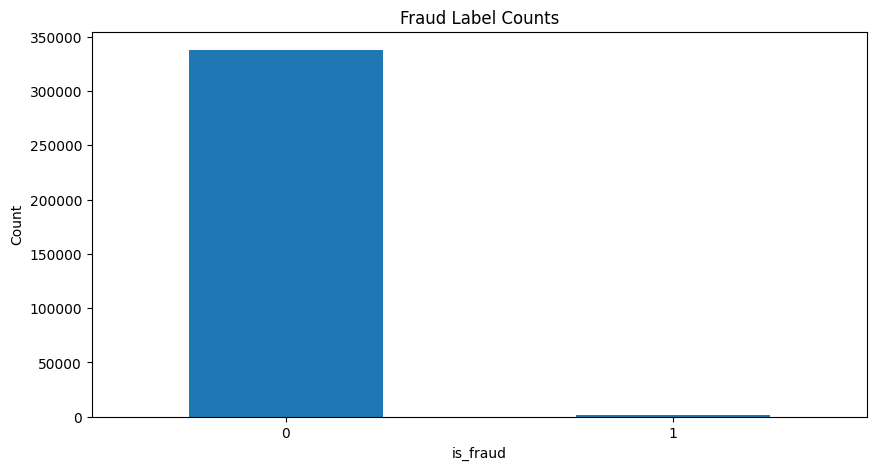

In [18]:
fraud_counts.plot(kind="bar")
plt.title("Fraud Label Counts")
plt.xlabel("is_fraud")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

## 12. Numeric feature distributions and sanity checks

In [19]:
numeric_cols = eda_df.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns:")
print(numeric_cols)

display(eda_df[numeric_cols].describe().T)

Numeric columns:
['amt', 'lat', 'long', 'city_pop', 'merch_lat', 'merch_long', 'is_fraud']


,count,mean,std,min,25%,50%,75%,max
amt,"339,607.0000",70.5780,161.6752,1.0000,9.6000,46.4600,83.3500,"28,948.9000"
lat,"339,607.0000",39.7190,5.0950,20.0271,36.7154,39.6171,41.7100,66.6933
long,"339,607.0000",-110.6226,12.6514,-165.6723,-120.0936,-111.0985,-100.6215,-89.6287
city_pop,"339,607.0000","107,140.8655","293,029.8873",46.0000,471.0000,"1,645.0000","35,439.0000","2,383,912.0000"
merch_lat,"339,607.0000",39.7189,5.1309,19.0274,36.8172,39.5862,42.1931,67.5103
merch_long,"339,607.0000",-110.6224,12.6640,-166.6716,-119.8238,-111.0364,-100.3531,-88.6292
is_fraud,"339,607.0000",0.0052,0.0722,0.0000,0.0000,0.0000,0.0000,1.0000


Histogram: amt


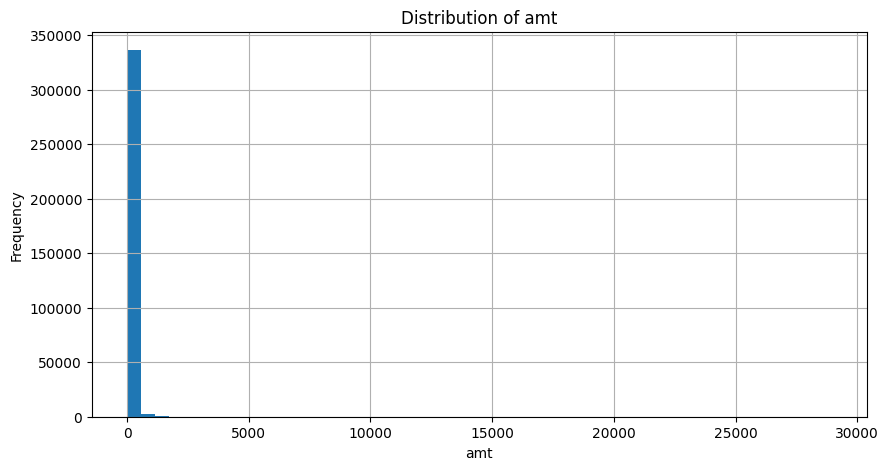

Histogram: city_pop


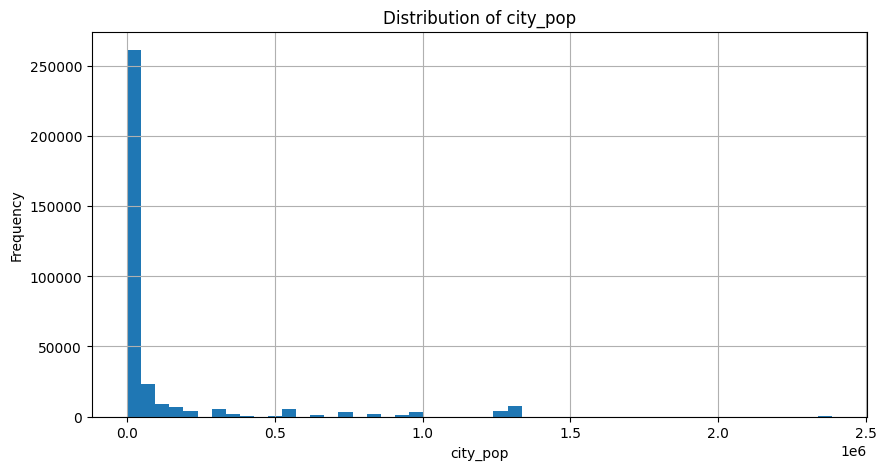

Histogram: lat


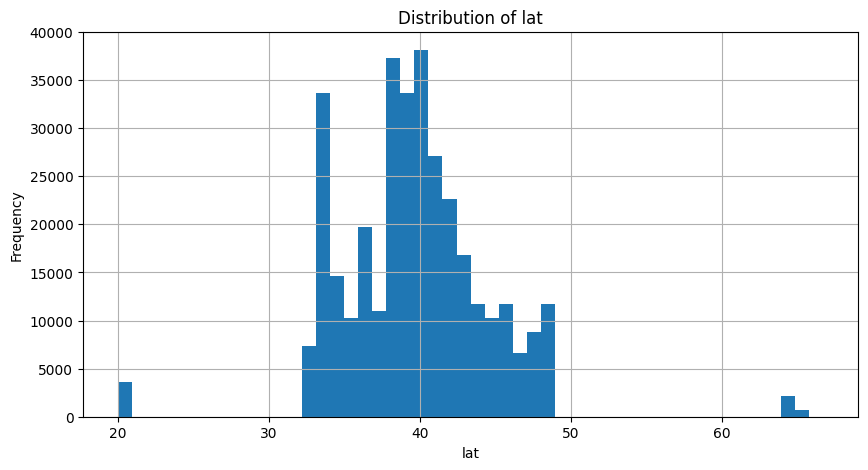

Histogram: long


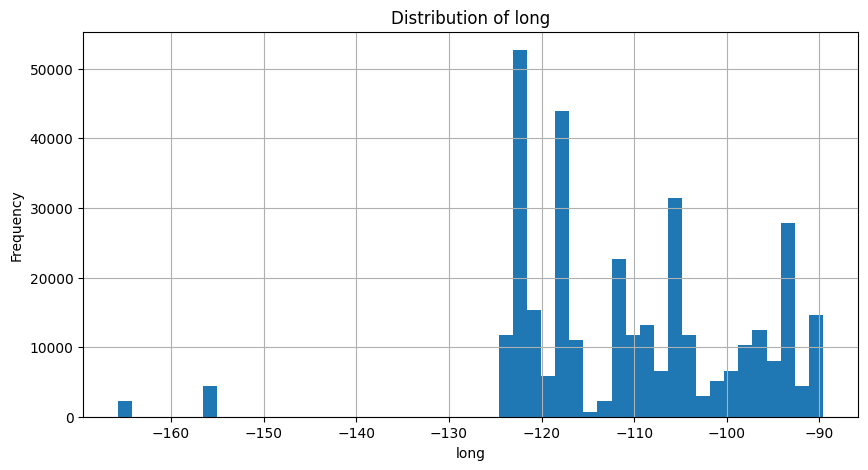

Histogram: merch_lat


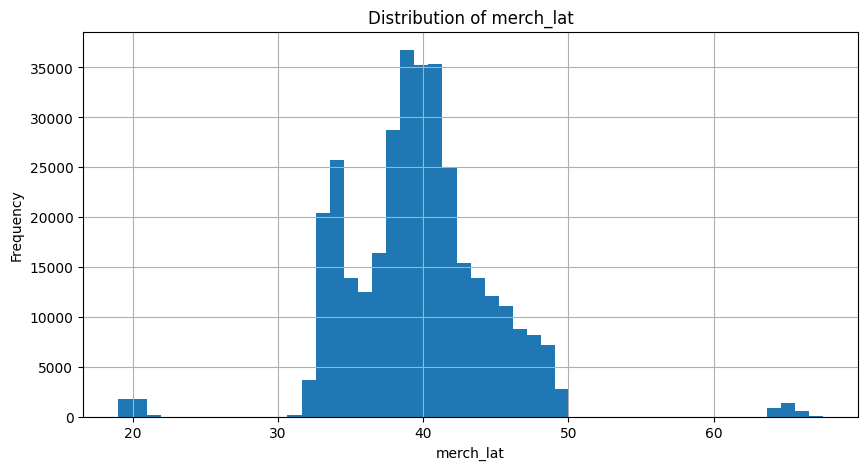

Histogram: merch_long


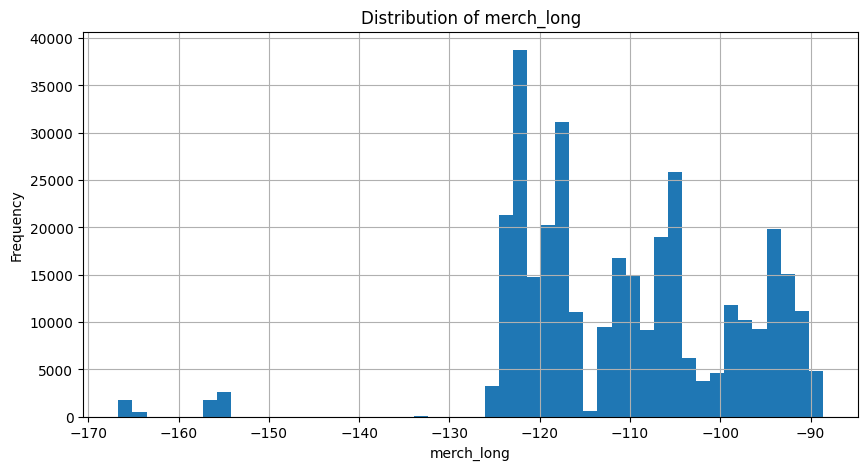

In [20]:
for col in ["amt", "city_pop", "lat", "long", "merch_lat", "merch_long"]:
    print(f"Histogram: {col}")
    eda_df[col].hist(bins=50)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

### Coordinate sanity checks

Latitude should generally be between -90 and 90, and longitude between -180 and 180.

In [21]:
coord_checks = {
    "lat_out_of_range": ((eda_df["lat"] < -90) | (eda_df["lat"] > 90)).sum(),
    "long_out_of_range": ((eda_df["long"] < -180) | (eda_df["long"] > 180)).sum(),
    "merch_lat_out_of_range": ((eda_df["merch_lat"] < -90) | (eda_df["merch_lat"] > 90)).sum(),
    "merch_long_out_of_range": ((eda_df["merch_long"] < -180) | (eda_df["merch_long"] > 180)).sum(),
}

display(pd.DataFrame.from_dict(coord_checks, orient="index", columns=["count"]))

,count
lat_out_of_range,0
long_out_of_range,0
merch_lat_out_of_range,0
merch_long_out_of_range,0


## 13. Categorical exploration

We inspect the most common values for key text columns.

In [22]:
categorical_cols = ["merchant", "category", "city", "state", "job"]

for col in categorical_cols:
    print(f"Top 15 values for: {col}")
    display(eda_df[col].value_counts().head(15).to_frame("count"))

Top 15 values for: merchant


,count
merchant,
Kilback LLC,1149
Cormier LLC,985
Schumm PLC,931
Kuhn LLC,896
Dickinson Lt,891
Boyer PLC,869
"Christiansen, Goyette and Schamberge",750
Erdman-Kertzmann,746
Bartoletti-Wunsch,741


Top 15 values for: category


,count
category,
gas_transport,35089
grocery_pos,32732
home,32516
shopping_pos,30329
kids_pets,29704
shopping_net,26379
personal_care,24406
entertainment,24222
food_dining,23038


Top 15 values for: city


,count
city,
Phoenix,7297
Fort Washakie,5116
Thompson,4386
Superior,4383
Conway,4381
Centerview,4380
Rocky Mount,4379
Sun City,4378
Sutherland,4378


Top 15 values for: state


,count
state,
CA,80495
MO,54904
NE,34425
WY,27776
WA,27040
OR,26408
NM,23427
CO,19766
AZ,15362


Top 15 values for: job


,count
job,
"Surveyor, minerals",6589
"Surveyor, land/geomatics",5855
Land/geomatics surveyor,5119
Insurance broker,5108
Systems analyst,4398
Geoscientist,4389
Petroleum engineer,4383
"Research officer, political party",4381
Electronics engineer,4380


## 14. Datetime feature engineering

Fraud often depends on *when* a transaction happens, so extracting time-based features is useful.

In [23]:
eda_df["trans_hour"] = eda_df["trans_date_trans_time"].dt.hour
eda_df["trans_day_of_week"] = eda_df["trans_date_trans_time"].dt.dayofweek
eda_df["trans_day_name"] = eda_df["trans_date_trans_time"].dt.day_name()
eda_df["trans_month"] = eda_df["trans_date_trans_time"].dt.month
eda_df["trans_year"] = eda_df["trans_date_trans_time"].dt.year

eda_df["age"] = ((eda_df["trans_date_trans_time"] - eda_df["dob"]).dt.days / 365.25).astype(float)

datetime_feature_preview = eda_df[
    ["trans_date_trans_time", "dob", "trans_hour", "trans_day_of_week", "trans_day_name", "trans_month", "trans_year", "age"]
].head(10)

display(datetime_feature_preview)

,trans_date_trans_time,dob,trans_hour,trans_day_of_week,trans_day_name,trans_month,trans_year,age
0,2019-01-01 00:00:44,1978-06-21,0,1,Tuesday,1,2019,40.5311
1,2019-01-01 00:00:51,1962-01-19,0,1,Tuesday,1,2019,56.9500
2,2019-01-01 00:07:27,1945-12-21,0,1,Tuesday,1,2019,73.0294
3,2019-01-01 00:09:03,1967-08-30,0,1,Tuesday,1,2019,51.3402
4,2019-01-01 00:21:32,1967-08-02,0,1,Tuesday,1,2019,51.4168
5,2019-01-01 00:22:06,1966-12-03,0,1,Tuesday,1,2019,52.0794
6,2019-01-01 00:22:18,1945-03-15,0,1,Tuesday,1,2019,73.7988
7,2019-01-01 00:22:36,1961-05-19,0,1,Tuesday,1,2019,57.6208
8,2019-01-01 00:31:51,1987-04-23,0,1,Tuesday,1,2019,31.6934
9,2019-01-01 00:34:10,1984-09-01,0,1,Tuesday,1,2019,34.3326


Transaction hour distribution:


,count
trans_hour,
0,11039
1,11241
2,11019
3,11227
4,10904
5,11023
6,11145
7,11094
8,11123


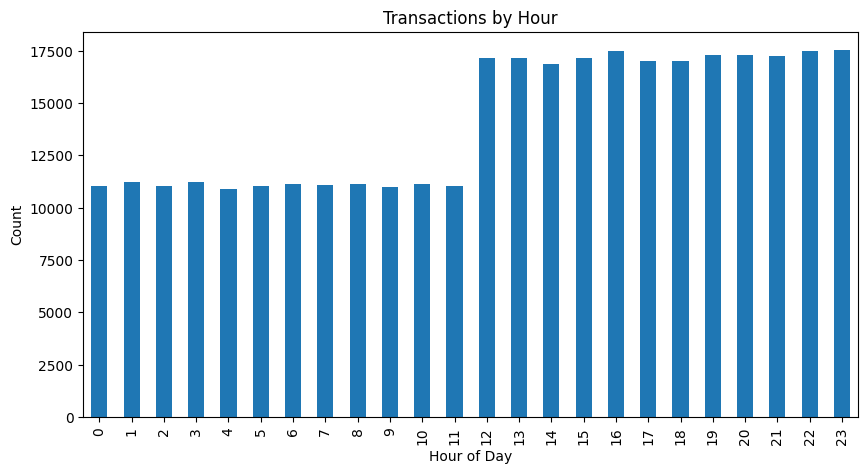

In [24]:
print("Transaction hour distribution:")
display(eda_df["trans_hour"].value_counts().sort_index().to_frame("count"))

eda_df["trans_hour"].value_counts().sort_index().plot(kind="bar")
plt.title("Transactions by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Count")
plt.show()

In [25]:
print("Transactions by day of week:")
display(eda_df["trans_day_name"].value_counts().to_frame("count"))

Transactions by day of week:


,count
trans_day_name,
Monday,67396
Sunday,62178
Tuesday,50051
Saturday,47884
Friday,39818
Thursday,38277
Wednesday,34003


### Age sanity check

In [26]:
display(eda_df["age"].describe().to_frame("value"))

print("Potentially suspicious ages (< 0 or > 110):")
suspicious_age_rows = eda_df[(eda_df["age"] < 0) | (eda_df["age"] > 110)]
print(f"Count: {len(suspicious_age_rows):,}")
if len(suspicious_age_rows) > 0:
    display(suspicious_age_rows[["dob", "trans_date_trans_time", "age"]].head(20))

,value
count,"339,607.0000"
mean,47.7952
std,17.0209
min,17.4346
25%,34.4805
50%,45.7303
75%,58.3080
max,93.3114


Potentially suspicious ages (< 0 or > 110):
Count: 0


## 15. Location-based feature engineering

Because we have both customer coordinates and merchant coordinates, we can compute the distance between them.

This may be useful for fraud detection because unusually large distances can be suspicious.

In [27]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0  # Earth radius in kilometers

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

eda_df["distance_km"] = haversine(
    eda_df["lat"],
    eda_df["long"],
    eda_df["merch_lat"],
    eda_df["merch_long"]
)

display(eda_df["distance_km"].describe().to_frame("value"))

,value
count,"339,607.0000"
mean,75.5776
std,29.0544
min,0.2051
25%,54.7341
50%,77.6126
75%,97.9478
max,152.1172


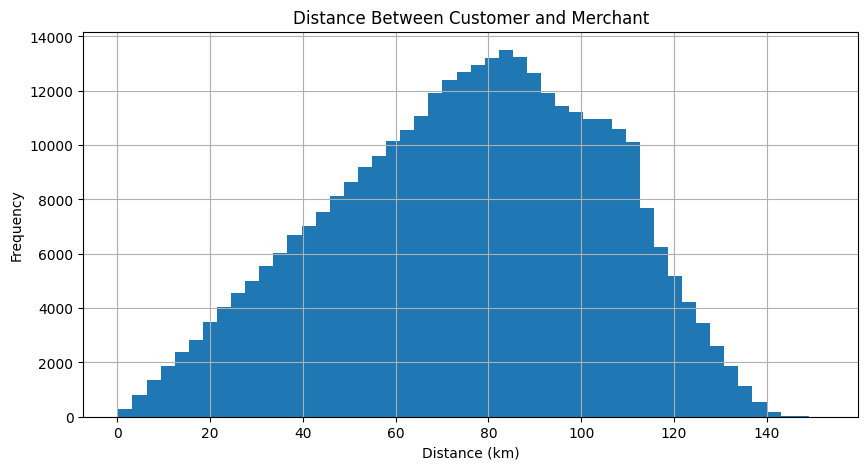

In [28]:
eda_df["distance_km"].hist(bins=50)
plt.title("Distance Between Customer and Merchant")
plt.xlabel("Distance (km)")
plt.ylabel("Frequency")
plt.show()

## 16. Compare fraud vs non-fraud on important numeric variables

This gives a first look at whether fraud cases behave differently.

In [29]:
comparison_cols = ["amt", "city_pop", "age", "distance_km"]

fraud_group_summary = eda_df.groupby("is_fraud")[comparison_cols].agg(["mean", "median", "std", "min", "max"])
display(fraud_group_summary)

amt                                          city_pop  \
             mean   median      std    min         max         mean   
is_fraud                                                              
0         68.2175  46.2500 156.2516 1.0000 28,948.9000 107,091.1096   
1        518.0655 356.4350 389.6274 1.7800  1,371.8100 116,573.4125   

                                                  age                          \
             median          std min      max    mean  median     std     min   
is_fraud                                                                        
0        1,645.0000 292,955.8281  46  2383912 47.7796 45.7166 17.0123 17.4346   
1        1,645.0000 306,687.1287  46  2383912 50.7587 50.1944 18.3512 19.4825   

                 distance_km                                  
             max        mean  median     std    min      max  
is_fraud                                                      
0        93.3114     75.5777 77.6144 29.0574 0.2051 152.1172  
1        91.6632     75.5730 77.3644 28.4835 1.4495 142.4849

In [30]:
for col in ["amt", "distance_km", "age", "city_pop"]:
    print(f"Average {col} by fraud label:")
    display(eda_df.groupby("is_fraud")[col].mean().to_frame("mean"))

Average amt by fraud label:


,mean
is_fraud,
0,68.2175
1,518.0655


Average distance_km by fraud label:


,mean
is_fraud,
0,75.5777
1,75.5730


Average age by fraud label:


,mean
is_fraud,
0,47.7796
1,50.7587


Average city_pop by fraud label:


,mean
is_fraud,
0,"107,091.1096"
1,"116,573.4125"


## 17. Correlation matrix for numeric features

This helps identify strong linear relationships among numeric variables.

,amt,lat,long,city_pop,merch_lat,merch_long,is_fraud,trans_hour,trans_day_of_week,trans_month,trans_year,age,distance_km
amt,1.0000,0.0028,-0.0070,0.0060,0.0030,-0.0069,0.2010,-0.0326,-0.0012,-0.0011,-0.0015,-0.0115,0.0015
lat,0.0028,1.0000,-0.1514,-0.2363,0.9936,-0.1513,0.0092,-0.0123,0.0046,-0.0037,0.0000,0.1621,-0.0739
long,-0.0070,-0.1514,1.0000,-0.0661,-0.1504,0.9990,-0.0045,0.0221,0.0008,-0.0003,0.0007,-0.0921,0.0192
city_pop,0.0060,-0.2363,-0.0661,1.0000,-0.2350,-0.0661,0.0023,0.0093,-0.0011,0.0009,-0.0022,-0.1353,0.0192
merch_lat,0.0030,0.9936,-0.1504,-0.2350,1.0000,-0.1503,0.0088,-0.0120,0.0046,-0.0036,0.0000,0.1612,-0.0739
merch_long,-0.0069,-0.1513,0.9990,-0.0661,-0.1503,1.0000,-0.0045,0.0220,0.0006,-0.0002,0.0008,-0.0918,0.0193
is_fraud,0.2010,0.0092,-0.0045,0.0023,0.0088,-0.0045,1.0000,0.0124,0.0021,-0.0178,-0.0070,0.0126,-0.0000
trans_hour,-0.0326,-0.0123,0.0221,0.0093,-0.0120,0.0220,0.0124,1.0000,-0.0004,-0.0022,0.0004,-0.1575,0.0018
trans_day_of_week,-0.0012,0.0046,0.0008,-0.0011,0.0046,0.0006,0.0021,-0.0004,1.0000,-0.0038,-0.0764,-0.0050,0.0007
trans_month,-0.0011,-0.0037,-0.0003,0.0009,-0.0036,-0.0002,-0.0178,-0.0022,-0.0038,1.0000,0.0026,0.0175,0.0009


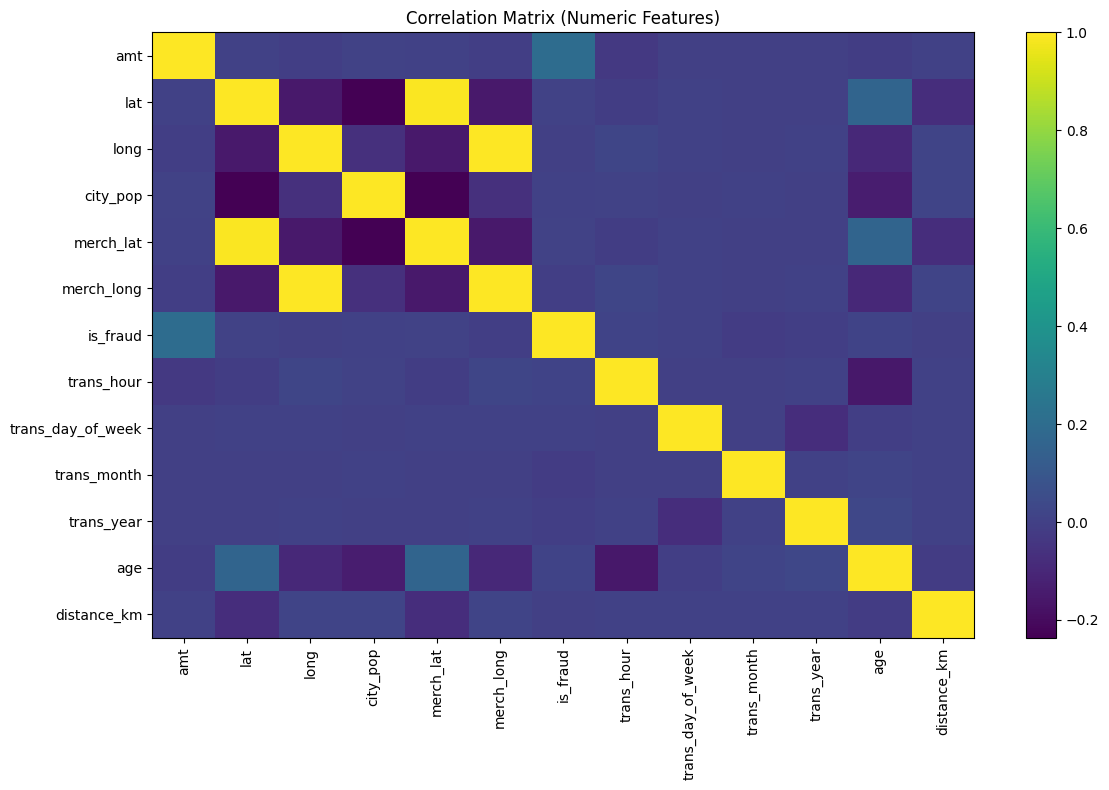

In [31]:
corr = eda_df.select_dtypes(include=[np.number]).corr()
display(corr)

plt.figure(figsize=(12, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix (Numeric Features)")
plt.tight_layout()
plt.show()

## 18. Potential outlier review

This does not automatically remove outliers. It simply helps identify extreme values worth inspecting.

In [32]:
for col in ["amt", "city_pop", "distance_km", "age"]:
    q1 = eda_df[col].quantile(0.25)
    q3 = eda_df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outlier_count = ((eda_df[col] < lower) | (eda_df[col] > upper)).sum()

    print(f"{col}")
    print(f"  Q1: {q1:,.4f}")
    print(f"  Q3: {q3:,.4f}")
    print(f"  IQR: {iqr:,.4f}")
    print(f"  Lower bound: {lower:,.4f}")
    print(f"  Upper bound: {upper:,.4f}")
    print(f"  Outlier count: {outlier_count:,}")
    print()

amt
  Q1: 9.6000
  Q3: 83.3500
  IQR: 73.7500
  Lower bound: -101.0250
  Upper bound: 193.9750
  Outlier count: 18,043

city_pop
  Q1: 471.0000
  Q3: 35,439.0000
  IQR: 34,968.0000
  Lower bound: -51,981.0000
  Upper bound: 87,891.0000
  Outlier count: 65,168

distance_km
  Q1: 54.7341
  Q3: 97.9478
  IQR: 43.2137
  Lower bound: -10.0864
  Upper bound: 162.7683
  Outlier count: 0

age
  Q1: 34.4805
  Q3: 58.3080
  IQR: 23.8275
  Lower bound: -1.2608
  Upper bound: 94.0493
  Outlier count: 0



## 19. Cleaned working copy preview

This section creates a basic cleaned version for **exploration purposes only**:
- strip spaces
- remove quote characters
- lowercase text
- parse datetimes
- add engineered features

You can later turn this into your actual preprocessing pipeline if you want.

In [33]:
clean_df = df.copy()

for col in ["merchant", "category", "city", "state", "job"]:
    clean_df[col] = (
        clean_df[col]
        .astype(str)
        .str.strip()
        .str.replace('"', "", regex=False)
        .str.lower()
    )

clean_df["trans_date_trans_time"] = pd.to_datetime(clean_df["trans_date_trans_time"], errors="coerce")
clean_df["dob"] = pd.to_datetime(clean_df["dob"], errors="coerce")

clean_df["trans_hour"] = clean_df["trans_date_trans_time"].dt.hour
clean_df["trans_day_of_week"] = clean_df["trans_date_trans_time"].dt.dayofweek
clean_df["trans_month"] = clean_df["trans_date_trans_time"].dt.month
clean_df["age"] = ((clean_df["trans_date_trans_time"] - clean_df["dob"]).dt.days / 365.25).astype(float)

clean_df["distance_km"] = haversine(
    clean_df["lat"], clean_df["long"], clean_df["merch_lat"], clean_df["merch_long"]
)

print("Preview of cleaned working copy:")
display(clean_df.head())

Preview of cleaned working copy:


,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud,trans_hour,trans_day_of_week,trans_month,age,distance_km
0,2019-01-01 00:00:44,"heller, gutmann and zieme",grocery_pos,107.2300,orient,wa,48.8878,-118.2105,149,special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,49.1590,-118.1865,0,0,1,1,40.5311,30.2122
1,2019-01-01 00:00:51,lind-buckridge,entertainment,220.1100,malad city,id,42.1808,-112.2620,4154,nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,43.1507,-112.1545,0,0,1,1,56.9500,108.2061
2,2019-01-01 00:07:27,kiehn inc,grocery_pos,96.2900,grenada,ca,41.6125,-122.5258,589,systems analyst,1945-12-21,413636e759663f264aae1819a4d4f231,41.6575,-122.2303,0,0,1,1,73.0294,25.0591
3,2019-01-01 00:09:03,beier-hyatt,shopping_pos,7.7700,high rolls mountain park,nm,32.9396,-105.8189,899,naval architect,1967-08-30,8a6293af5ed278dea14448ded2685fea,32.8633,-106.5202,0,0,1,1,51.3402,66.0217
4,2019-01-01 00:21:32,bruen-yost,misc_pos,6.8500,freedom,wy,43.0172,-111.0292,471,"education officer, museum",1967-08-02,f3c43d336e92a44fc2fb67058d5949e3,43.7537,-111.4549,0,0,1,1,51.4168,88.8310


## 20. Final takeaways

Use the output above to write a short summary for your project notes. In general, these are the kinds of conclusions this notebook is designed to support:

- Whether the dataset has missing values
- Whether there are exact duplicate rows
- Whether date columns need conversion
- Whether text columns have formatting inconsistencies
- Whether `trans_num` behaves like a unique ID
- How imbalanced the fraud target is
- Whether time-based and location-based features seem worth engineering
- Whether any numeric columns have suspicious outliers or skew

### Suggested next steps after this notebook
1. Finalize a cleaning pipeline
2. Decide which columns to drop or encode
3. Build a train/test split
4. Start with a simple baseline model
5. Use metrics appropriate for imbalanced classification:
   - precision
   - recall
   - F1
   - ROC-AUC
   - PR-AUC